# Face Attributes Recognition with ResNet

Notebook này dùng **ResNet (ResNet-18)** làm backbone cho bài kết hợp:
- Nhận diện độ tuổi (age-group)
- Nhận diện giới tính (gender)
- Nhận diện chủng tộc / ethnicity (race)

Ta sẽ làm theo các bước:
1. Hướng dẫn tải dataset từ Kaggle (UTKFace)
2. Tạo `Dataset` đọc UTKFace (age, gender, race từ tên file)
3. Tạo `DataLoader`
4. Xây dựng **ResNet-18 multi-head** (3 output: age, gender, race)
5. Train 5 epoch → chọn model tốt nhất
6. Lưu checkpoint

> Bạn có thể mở rộng thêm head Emotion nếu sau này trộn FER2013 vào.

In [ ]:
! pip install -q kaggle

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
path = r'/content/drive/MyDrive/Nhom1_Py/Dataset'
os.listdir(path)

['utkface-new', 'fer2013', 'sample_img', 'ex_mobilenet', 'test_vgg']

In [ ]:
# !mkdir -p ~/.kaggle

In [ ]:
# !mv kaggle.json ~/.kaggle/

In [ ]:
# !chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# !kaggle datasets download -d msambare/fer2013 -p "/content/drive/MyDrive/Colab Notebooks/dataset" --force

In [ ]:
# !unzip "/content/drive/MyDrive/Colab Notebooks/dataset/fer2013.zip" -d "/content/drive/MyDrive/Colab Notebooks/dataset/fer2013"

In [ ]:
# !kaggle datasets download -d jangedoo/utkface-new -p "/content/drive/MyDrive/Colab Notebooks/dataset" --force

In [ ]:
# !unzip "/content/drive/MyDrive/Colab Notebooks/dataset/utkface-new.zip" -d "/content/drive/MyDrive/Colab Notebooks/dataset/utkface-new"

In [4]:
# 2. Import thư viện
import os, glob
from PIL import Image
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## 3. Dataset UTKFace

Tên file UTKFace: `age_gender_race_date.jpg`
- `age`: số nguyên (0–116)
- `gender`: 0 = male, 1 = female
- `race`: 0 = White, 1 = Black, 2 = Asian, 3 = Indian, 4 = Others

Ta sẽ map tuổi thành 5 nhóm để dễ train:
- 0: 0–12
- 1: 13–25
- 2: 26–40
- 3: 41–60
- 4: 61+


In [5]:
def age_to_group5(age: int) -> int:
    """
    Chia tuổi thành 5 nhóm:
    0: 0 - 18
    1: 19 - 30
    2: 31 - 45
    3: 46 - 60
    4: 61+
    """
    if age <= 18:
        return 0
    elif age <= 30:
        return 1
    elif age <= 45:
        return 2
    elif age <= 60:
        return 3
    else:
        return 4


class UTKFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        # lấy tất cả file ảnh có ext phổ biến
        exts = ['*.jpg', '*.jpeg', '*.png']
        self.image_paths = []

        for e in exts:
            self.image_paths.extend(glob.glob(os.path.join(root_dir, e)))

        self.image_paths.sort()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        filename = os.path.basename(img_path)

        # UTKFace format: age_gender_race_.jpg
        age, gender, race = map(int, filename.split('_')[:3])

        age_cls = age_to_group5(age)

        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)

        return {
            'image': img,
            'age_cls': age_cls,
            'gender': gender,
            'race': race
        }

In [6]:
# 3.1. transforms & dataloaders
train_tfms = T.Compose([
    T.Resize((224,224)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_tfms = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Đổi path theo máy bạn
train_dir = "/content/drive/MyDrive/Nhom1_Py/Dataset/utkface-new/train"
val_dir = "/content/drive/MyDrive/Nhom1_Py/Dataset/utkface-new/val"

if os.path.exists(train_dir):
    train_ds = UTKFaceDataset(train_dir, transform=train_tfms)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4)
else:
    train_ds = None
    train_loader = None

if os.path.exists(val_dir):
    val_ds = UTKFaceDataset(val_dir, transform=val_tfms)
    val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=4)
else:
    val_ds = None
    val_loader = None

train_ds

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## 4. ResNet-18 Multi-head

Ta sẽ dùng backbone **resnet18** pretrained trên ImageNet, sau đó thay phần cuối bằng 1 MLP chung rồi tách 3 head:
- Age (5 lớp)
- Gender (2 lớp)
- Race (5 lớp)


In [7]:
class ResNetMultiHead(nn.Module):
    def __init__(self, num_age=5, num_gender=2, num_race=5):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # bỏ fc cuối
        self.features = nn.Sequential(*list(base.children())[:-1])  # output: (B, 512, 1, 1)

        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.age_head = nn.Linear(256, num_age)
        self.gender_head = nn.Linear(256, num_gender)
        self.race_head = nn.Linear(256, num_race)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        age_logits = self.age_head(x)
        gender_logits = self.gender_head(x)
        race_logits = self.race_head(x)
        return age_logits, gender_logits, race_logits

model = ResNetMultiHead().to(device)
model

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s]


ResNetMultiHead(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_st

## 5. Hàm train / eval 5 epoch

Ta sẽ cộng 3 loss lại. Nếu bạn muốn ưu tiên task nào hơn (ví dụ age) thì nhân hệ số.

In [8]:
def train_one_epoch(model, loader, optimizer, ce_age, ce_gender, ce_race, lambda_age, lambda_gender, lambda_race):
    model.train()
    running_loss = 0.0
    for batch in loader:
        imgs = batch['image'].to(device)
        age = batch['age_cls'].to(device)
        gender = batch['gender'].to(device)
        race = batch['race'].to(device)

        optimizer.zero_grad()
        age_logits, gender_logits, race_logits = model(imgs)

        loss_age = ce_age(age_logits, age)
        loss_gender = ce_gender(gender_logits, gender)
        loss_race = ce_race(race_logits, race)

        # ÁP DỤNG TRỌNG SỐ Ở ĐÂY
        loss = lambda_age * loss_age + lambda_gender * loss_gender + lambda_race * loss_race

        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

    return running_loss / len(loader.dataset)

In [9]:
@torch.no_grad()
def eval_one_epoch(model, loader, ce_age, ce_gender, ce_race, lambda_age, lambda_gender, lambda_race):
    model.eval()
    total = 0
    run_loss = 0.0
    correct_age = 0
    correct_gender = 0
    correct_race = 0
    for batch in loader:
        imgs = batch['image'].to(device)
        age = batch['age_cls'].to(device)
        gender = batch['gender'].to(device)
        race = batch['race'].to(device)

        age_logits, gender_logits, race_logits = model(imgs)

        loss_age = ce_age(age_logits, age)
        loss_gender = ce_gender(gender_logits, gender)
        loss_race = ce_race(race_logits, race)

        # ÁP DỤNG TRỌNG SỐ CHO VAL_LOSS (ĐỂ TÍNH NHẤT QUÁN)
        loss = lambda_age * loss_age + lambda_gender * loss_gender + lambda_race * loss_race

        run_loss += loss.item() * imgs.size(0)

        _, age_pred = age_logits.max(1)
        _, gender_pred = gender_logits.max(1)
        _, race_pred = race_logits.max(1)

        correct_age += (age_pred == age).sum().item()
        correct_gender += (gender_pred == gender).sum().item()
        correct_race += (race_pred == race).sum().item()
        total += imgs.size(0)

    avg_loss = run_loss / len(loader.dataset)
    age_acc = correct_age / total
    gender_acc = correct_gender / total
    race_acc = correct_race / total
    return avg_loss, age_acc, gender_acc, race_acc

In [11]:
# 6. Train 10 epoch
num_epochs = 5
ce_age = nn.CrossEntropyLoss()
ce_gender = nn.CrossEntropyLoss()
ce_race = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

best_val_loss = float('inf')
best_state = None

# ĐỊNH NGHĨA TRỌNG SỐ CHO CÁC TÁC VỤ
# Loss = lambda_age * Loss_age + lambda_gender * Loss_gender + ...
# Đặt trọng số tuổi cao hơn để mô hình tập trung vào tác vụ khó hơn
lambda_age = 2.0
lambda_gender = 1.0
lambda_race = 1.0

if train_loader is not None and val_loader is not None:
    for epoch in range(num_epochs):
        # SỬA train_one_epoch ĐỂ SỬ DỤNG TRỌNG SỐ
        train_loss = train_one_epoch(model, train_loader, optimizer, ce_age, ce_gender, ce_race, lambda_age, lambda_gender, lambda_race)
        # SỬA eval_one_epoch ĐỂ SỬ DỤNG TRỌNG SỐ
        # CẦN TRUYỀN THÊM CÁC HỆ SỐ NÀY VÀO HÀM train/eval
        val_loss, age_acc, gender_acc, race_acc = eval_one_epoch(model, val_loader, ce_age, ce_gender, ce_race, lambda_age, lambda_gender, lambda_race)
        print(f"Epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | age_acc={age_acc:.3f} | gender_acc={gender_acc:.3f} | race_acc={race_acc:.3f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
else:
    print("⚠️ Chưa tìm thấy dữ liệu. Hãy tải UTKFace và đặt vào data/utkface/train, data/utkface/val")

Epoch 1/1 | train_loss=2.9483 | val_loss=2.2445 | age_acc=0.753 | gender_acc=0.837 | race_acc=0.758


In [ ]:
# 7. Lưu model tốt nhất
if best_state is not None:
    os.makedirs('checkpoints', exist_ok=True)
    torch.save(best_state, 'checkpoints/resnet_multihead_best.pth')
    print('✅ Đã lưu checkpoints/resnet_multihead_best.pth')
else:
    print('⚠️ Không có model để lưu (có thể chưa train do thiếu data)')

NameError: name 'best_state' is not defined

In [ ]:
!cp "checkpoints/resnet_multihead_best.pth" "/content/drive/MyDrive/Nhom1_Py"

In [ ]:
# Load model
model = ResNetMultiHead().to(device)

checkpoint = torch.load("/content/drive/MyDrive/Nhom1_Py/resnet_multihead_best.pth", map_location=device)
model.load_state_dict(checkpoint)

model.eval()
print(">> Model loaded successfully!")

NameError: name 'ResNetMultiHead' is not defined

In [ ]:
from torchvision import transforms

transform_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from PIL import Image

def predict_image(img_path):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform_test(img).unsqueeze(0).to(device)

    with torch.no_grad():
        age_logits, gender_logits, race_logits = model(img_tensor)

    age_pred = torch.argmax(age_logits, dim=1).item()
    gender_pred = torch.argmax(gender_logits, dim=1).item()
    race_pred = torch.argmax(race_logits, dim=1).item()

    return age_pred, gender_pred, race_pred

In [ ]:
import os
import glob

folder_path = "/content/drive/MyDrive/Nhom1_Py/Dataset/sample_img"

img_list = glob.glob(folder_path + "/*.jpg") \
         + glob.glob(folder_path + "/*.png") \
         + glob.glob(folder_path + "/*.jpeg")

print(f"Tìm thấy {len(img_list)} ảnh để predict!")
age_labels = ["0-18", "19-30", "31-45", "46-60", "61+"]
gender_labels = ["Female", "Male"]
race_labels = ["White", "Black", "Asian", "Indian", "Others"]



Tìm thấy 7 ảnh để predict!


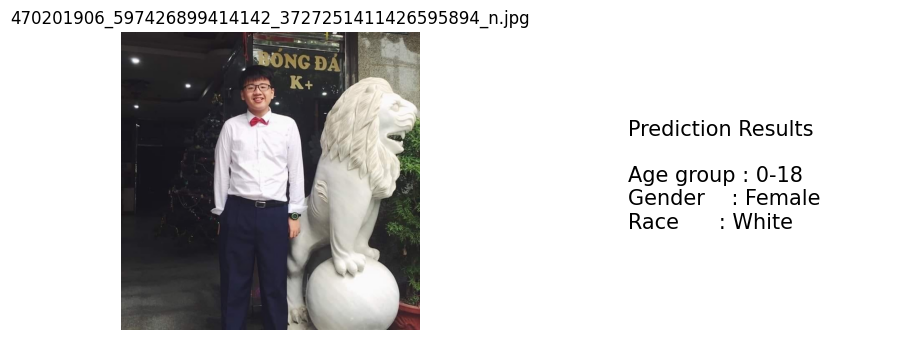

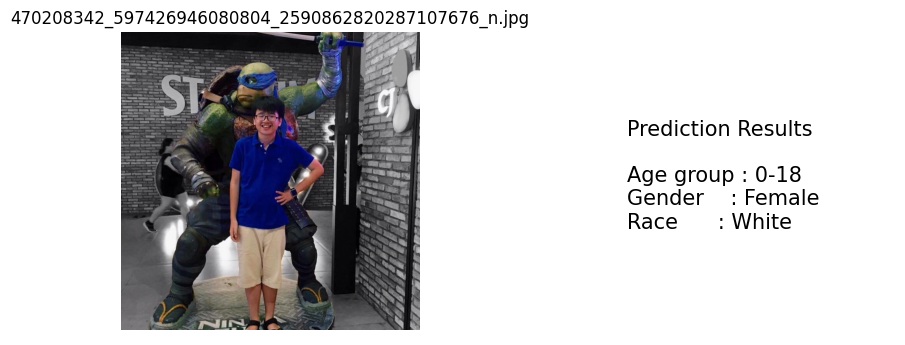

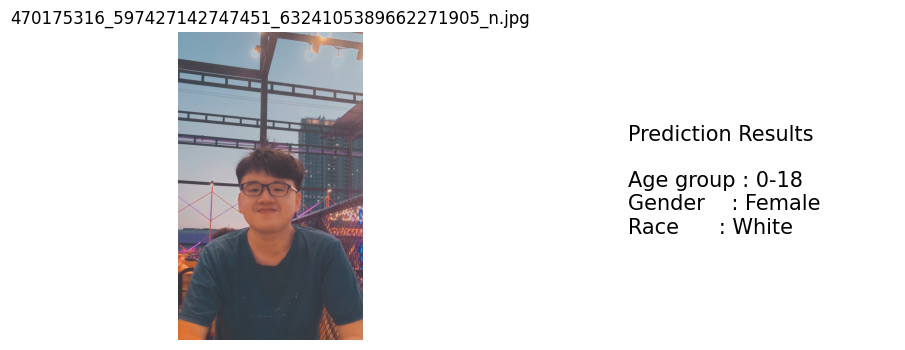

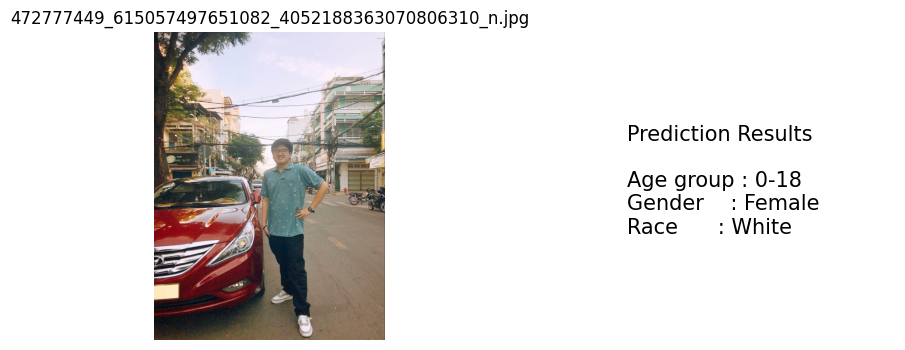

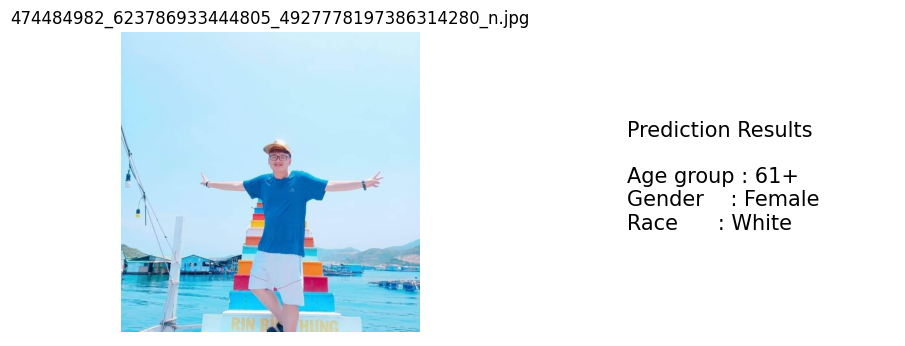

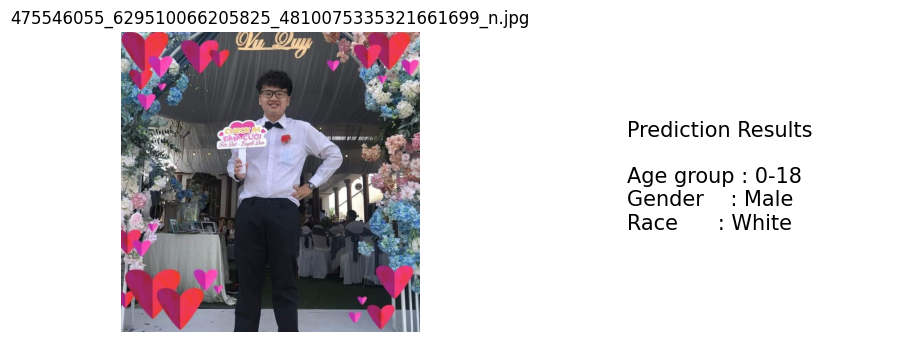

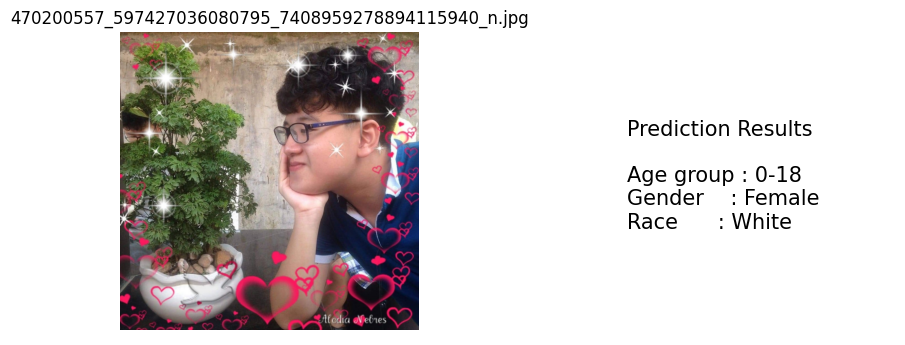

In [ ]:
import matplotlib.pyplot as plt

for img_path in img_list:
    age, gender, race = predict_image(img_path)

    img = Image.open(img_path)

    fig = plt.figure(figsize=(10, 4))  # chiều ngang dài hơn để có khoảng trống

    # --- Hiển thị ảnh ---
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title(os.path.basename(img_path))

    # --- Hiển thị thông tin ---
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.axis('off')

    text = (
        f"Prediction Results\n\n"
        f"Age group : {age_labels[age]}\n"
        f"Gender    : {gender_labels[gender]}\n"
        f"Race      : {race_labels[race]}"
    )

    ax2.text(
        0.1, 0.7,        # càng lớn càng lùi sang phải/đi lên
        text,
        fontsize=15,
        va='top'
    )

    # tăng khoảng cách giữa các cột
    plt.subplots_adjust(wspace=0.6)

    plt.show()
